# **Week 6 Assignment :**
# PROBLEM STATEMENT : Build a deep learning model that can remove noise from images using an autoencoder on MNIST

#1. Import Required Libraries :

In [1]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

#2. Load and Preprocess the MNIST Dataset :

In [2]:
# Load the MNIST dataset

(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##2.1. Check the Dataset Shape

In [3]:
# Display dataset information

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape :", x_test.shape)

Training Images Shape: (60000, 28, 28)
Testing Images Shape : (10000, 28, 28)


##2.2. Normalize the Images

In [4]:
# Normalize pixel values

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

##2.3. Reshape the Images

In [5]:
# Reshape images for the convolutional autoencoder

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

##2.4. Verify the New Shape

In [6]:
print("Training Images Shape after preprocessing:", x_train.shape)
print("Testing Images Shape after preprocessing :", x_test.shape)

Training Images Shape after preprocessing: (60000, 28, 28, 1)
Testing Images Shape after preprocessing : (10000, 28, 28, 1)


# 3. Add Artificial Noise to Images :

##3.1. Add Gaussian Noise

In [7]:
# Set the noise factor
noise_factor = 0.5

# Add Gaussian noise
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

##3.2. Clip Pixel Values

In [8]:
# Keep pixel values within the valid range

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

##3.3. Visualize Original vs Noisy Images

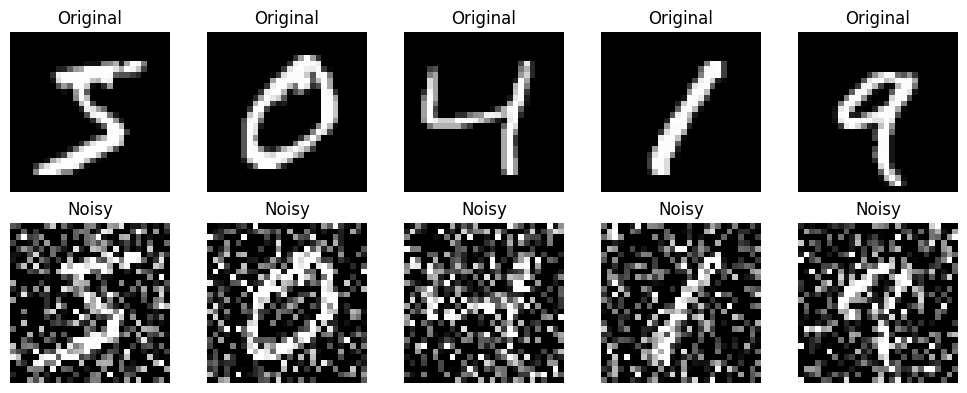

In [9]:
# Display original and noisy images

plt.figure(figsize=(10, 4))

for i in range(5):

    # Original image
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy image
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

#4.  Build the Denoising Autoencoder :

In [10]:
# Define the input layer
input_img = Input(shape=(28, 28, 1))

#Encoder

x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = MaxPooling2D((2, 2), padding="same")(x)

x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2, 2), padding="same")(x)

#Decoder

x = Conv2D(32, (3, 3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

# Create the Autoencoder model
autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### Building the Denoising Autoencoder

The denoising autoencoder is designed to learn the mapping from **noisy images** to their corresponding **clean images**. It consists of two main components:

- **Encoder:** Compresses the input image and extracts important features.
- **Decoder:** Reconstructs the image from the compressed representation to produce a denoised output.

### Architecture

```
Input Image (28 × 28 × 1)
        │
     Conv2D (32)
        │
   MaxPooling2D
        │
     Conv2D (32)
        │
   MaxPooling2D
        │
Compressed Representation
        │
     Conv2D (32)
        │
   UpSampling2D
        │
     Conv2D (32)
        │
   UpSampling2D
        │
 Conv2D (1, Sigmoid)
        │
 Denoised Image (28 × 28 × 1)
```

#5. Compile and Train the Autoencoder :

##5.1. Compile the Model

In [11]:
# Compile the autoencoder

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

##5.2. Train the Model

In [ ]:
# Train the autoencoder

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 283ms/step - loss: 0.1632 - val_loss: 0.1160
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 289ms/step - loss: 0.1116 - val_loss: 0.1067
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 279ms/step - loss: 0.1063 - val_loss: 0.1038
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 284ms/step - loss: 0.1037 - val_loss: 0.1016
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 289ms/step - loss: 0.1020 - val_loss: 0.1006
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 280ms/step - loss: 0.1008 - val_loss: 0.0998
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 279ms/step - loss: 0.1000 - val_loss: 0.0987
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 128s 273ms/step - loss: 0.0992 - val_loss: 0.0979
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 129s 275ms/step - loss: 0.0986 - val_loss: 0.0975
Epoch 10/10
401/469 ━━━━━━━━━━━━━━━━━━━━ 18s 268ms/step - loss: 0.0983

In [13]:
print(len(history.history["loss"]))
print(len(history.history["val_loss"]))

10
10


###Plot the Training Loss

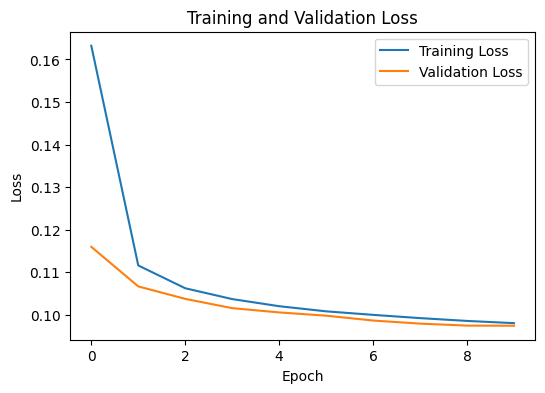

In [14]:
# Plot training and validation loss

plt.figure(figsize=(6,4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


### Observation

- The denoising autoencoder showed steady learning throughout the training process. The **training loss** decreased from **0.1632** in the first epoch to **0.0978** in the final epoch, while the **validation loss** decreased from **0.1160** to **0.0975**. The close alignment between the training and validation loss curves indicates that the model generalized well to unseen data without significant overfitting. Overall, the model converged successfully and learned to reconstruct cleaner images from noisy inputs.

#6. Generate and Visualize Denoised Images :

In [15]:
# Generate denoised images
denoised_images = autoencoder.predict(x_test_noisy)

# Verify the output shape
print("Shape of Denoised Images:", denoised_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step
Shape of Denoised Images: (10000, 28, 28, 1)


##6.1. Visualize the Results

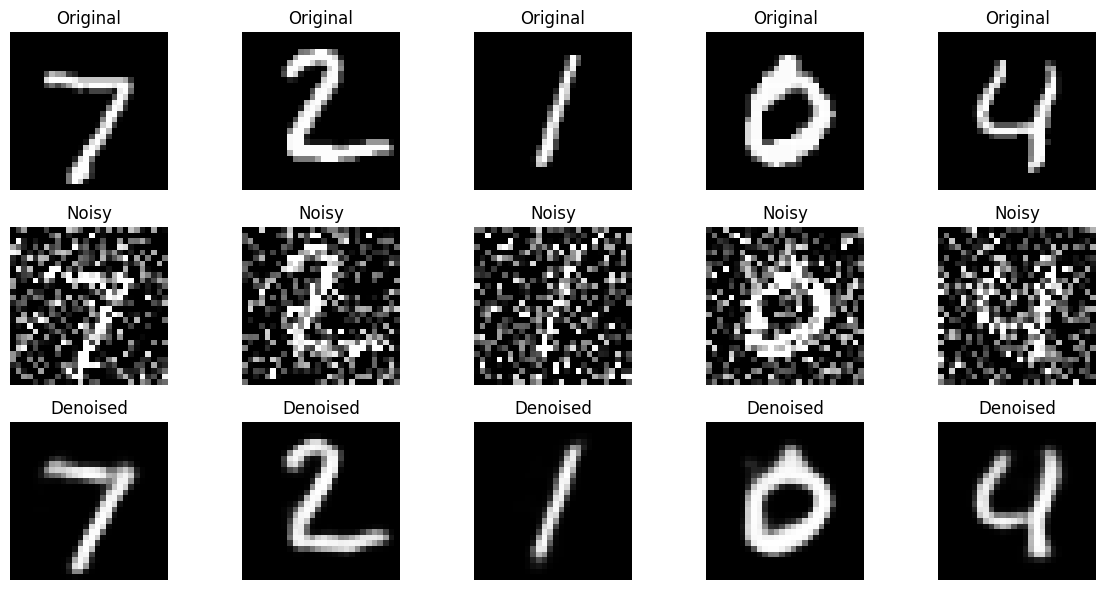

In [16]:
# Display original, noisy, and denoised images

n = 5
plt.figure(figsize=(12, 6))

for i in range(n):

    # Original Images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy Images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()


- The trained autoencoder is used to predict denoised images from the noisy test dataset. The results are visualized by comparing the **original**, **noisy**, and **denoised** images. This comparison demonstrates the model's ability to reconstruct cleaner images while preserving the important features of the handwritten digits.

#7. Results :

- The denoising autoencoder successfully learned to reconstruct clean handwritten digit images from noisy inputs.
- The training loss decreased from **0.1632** to **0.0978**, while the validation loss decreased from **0.1160** to **0.0975**, indicating stable learning and good generalization.
- The denoised images preserved the overall structure and shape of the original digits while effectively reducing the added Gaussian noise.
- The close alignment between the training and validation loss curves suggests that the model did not exhibit significant overfitting during training.
- Overall, the denoising autoencoder proved to be an effective deep learning approach for image denoising on the MNIST dataset.



#8. Challenges Faced :

- Selecting an appropriate noise level was important, as excessive noise can make image reconstruction more difficult.

- Balancing model complexity and training time was necessary to achieve good denoising performance while keeping the model computationally efficient.

- Ensuring that the reconstructed images preserved the original digit structure while effectively removing noise was a key objective during training

#9. Conclusion :

In this assignment, a **Denoising Autoencoder** was successfully implemented using the **MNIST** dataset to remove artificial Gaussian noise from handwritten digit images. The dataset was preprocessed, noisy images were generated, and the autoencoder was trained to reconstruct clean images from noisy inputs.

The model demonstrated effective learning, with the **training loss decreasing from 0.1632 to 0.0978** and the **validation loss decreasing from 0.1160 to 0.0975**, indicating stable convergence and good generalization. The visual comparison between the original, noisy, and denoised images showed that the autoencoder successfully reduced noise while preserving the essential features of the handwritten digits.

Overall, this project demonstrates the effectiveness of deep learning-based autoencoders for image denoising and highlights their practical application in image restoration tasks.